# 🧬 Cancer Subtype Discovery
## Notebook 02: Dimensionality Reduction (PCA)

**Dataset:** TCGA Pan-Cancer RNA-Seq — 801 patients | 20,531 genes

## 📌 Objective
Reduce 20,531 gene dimensions to 262 principal components (85% variance retained)
to make clustering computationally feasible and remove noise.

## 📋 Notebook Flow
1. Data Loading & Cleaning
2. StandardScaler — Feature Scaling
3. PCA — Explained Variance Analysis
4. Optimal Components Selection (85% threshold)
5. PCA Transform (20,531 → 262 dimensions)
6. 2D Scatter Plot — Cancer Type Visualization
7. Save Processed Data, Scaler & PCA Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

In [2]:
# 1── Data Loading & Cleaning ─────────────────────────────────────────
# Both CSV files contain an 'Unnamed: 0' column with sample IDs (sample_0, sample_1...)
# This column is not a feature — it's just a row identifier, so we drop it.
# From labels, we extract only the 'Class' column (cancer type) as our target variable y.
BASE_DIR = Path.cwd().parent

X = pd.read_csv(BASE_DIR / "data" / "raw" / 'data.csv')
labels = pd.read_csv(BASE_DIR / "data" / "raw" / 'labels.csv')

X = X.drop(columns=[X.columns[0]])   # Drop sample ID column (not a gene feature)
y = labels.iloc[:, 1]                 # Extract cancer type labels (BRCA, KIRC, COAD, LUAD, PRAD)

print("X shape:", X.shape)            # Expected: (801, 20531)
print("y shape:", y.shape)            # Expected: (801,)
print("Cancer types:", y.unique())    # Expected: 5 unique cancer types

X shape: (801, 20531)
y shape: (801,)
Cancer types: ['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']


In [3]:
# 2. StandardScaler — Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean():.4f}")
print(f"Std  (should be ~1): {X_scaled.std():.4f}")

Scaled data shape: (801, 20531)
Mean (should be ~0): 0.0000
Std  (should be ~1): 0.9935


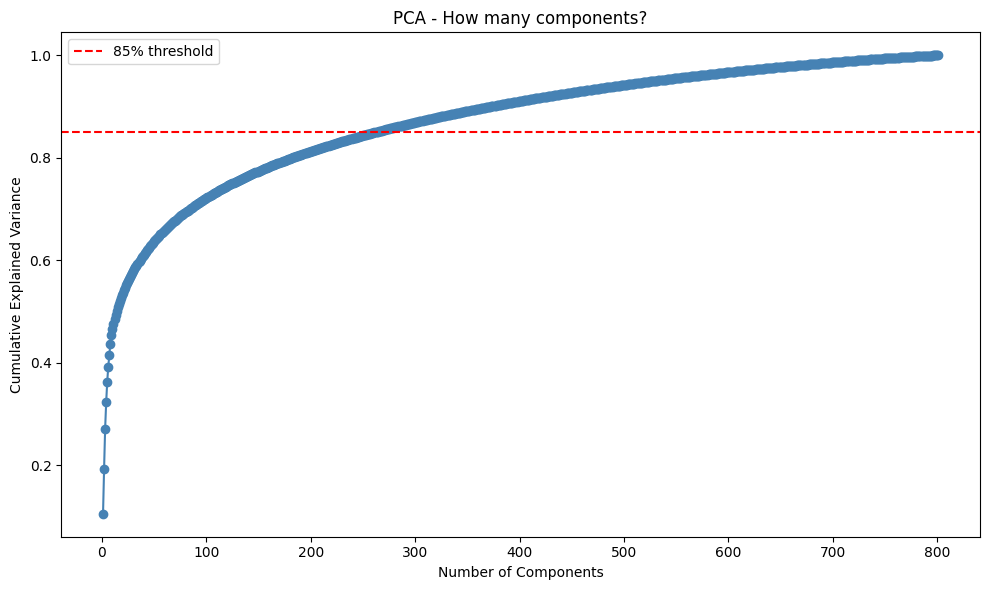

In [4]:
# 3. PCA — Explained Variance Analysis

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='steelblue')
plt.axhline(y=0.85, color='red', linestyle='--', label='85% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - How many components?')
plt.legend()
plt.tight_layout()
plt.savefig('../images/pca_explained_variance.png', dpi=150)
plt.show()


In [5]:
# 4. Optimal Components Selection (85% threshold)
n_for_85 = (cumulative >= 0.85).argmax() + 1
print(f"Components needed for 85% variance: {n_for_85}")
print(f"Variance explained by 262 components: {cumulative[261]:.4f}")

Components needed for 85% variance: 262
Variance explained by 262 components: 0.8500


In [6]:
# 5. PCA Transform (20,531 → 262 dimensions)

pca = PCA(n_components=262)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape}")
print(f"After PCA shape: {X_pca.shape}")


Original shape: (801, 20531)
After PCA shape: (801, 262)


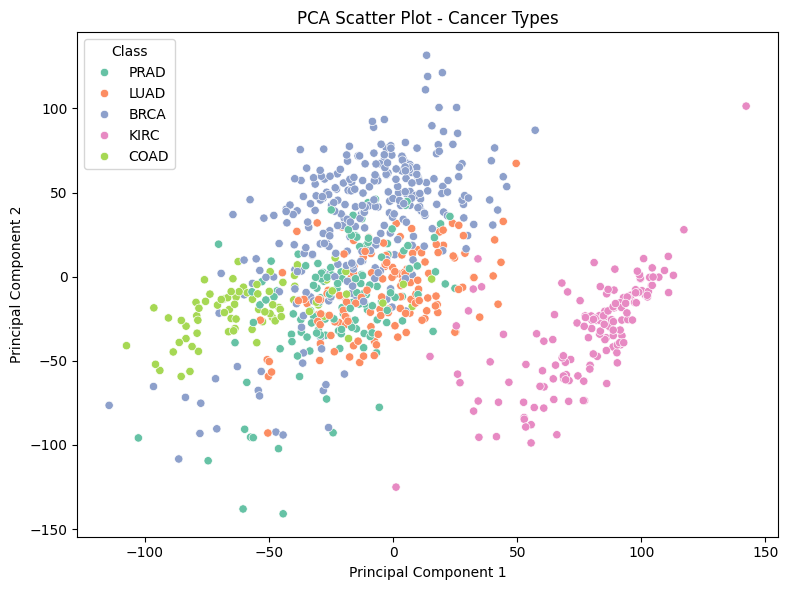

In [7]:
# 6. 2D Scatter Plot — Cancer Type Visualization

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,          
    palette='Set2'  
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot - Cancer Types")
plt.tight_layout()
plt.savefig('../images/pca_scatter.png', dpi=150)
plt.show()

## 📊 PCA Scatter Plot Analysis (PC1 vs PC2)

- **KIRC (pink):** Perfectly separated on the right side — most distinct cancer type.
  K-Means will easily identify this cluster.

- **COAD (yellow-green):** Mostly separated on the left side with slight overlap.
  Should form a recognizable cluster.

- **BRCA (blue):** Dominant in the center due to highest patient count (300).
  Shows some overlap with LUAD and PRAD.

- **PRAD (green) + LUAD (orange):** Overlapping in the center region.
  These two will be the most challenging for clustering to separate.

- **Key Insight:** Without using any labels, PCA has already revealed
  natural biological groupings in gene expression data — confirming that
  262 components carry meaningful cancer-type information.

In [8]:
# 7. Save Processed Data, Scaler & PCA Model

import joblib
import pandas as pd

# 1. PCA transformed data save
cols = [f'PC{i+1}' for i in range(262)]
# columns: PC1, PC2, PC3, ... PC262
df_pca = pd.DataFrame(X_pca, columns=cols)
df_pca.to_csv(BASE_DIR / "data" / "processed" / "data_processed.csv", index=False)

# 2. Scaler save
joblib.dump(scaler, BASE_DIR / "model" / "scaler.pkl")

# 3. PCA model save
joblib.dump(pca, BASE_DIR / "model" / "pca_model.pkl")

print("All saved successfully!")
print(f"  data_processed.csv → (801, 262)")
print(f"  scaler.pkl → StandardScaler fitted on 20531 genes")
print(f"  pca_model.pkl → PCA with 262 components")

All saved successfully!
  data_processed.csv → (801, 262)
  scaler.pkl → StandardScaler fitted on 20531 genes
  pca_model.pkl → PCA with 262 components
